# ⭐ Day 29: Regular Expressions Deep Dive

**Text Data Mastery for NLP & AI | Step-by-Step Tutorial with Examples & Exercises**

*Day 29 of 369-day Python & AI Learning Path* 🚀


## Welcome to Day 29!

Welcome to Day 29 of your Python & AI Learning Path! Today we're diving deep into one of the most powerful and versatile tools in a data scientist's arsenal: **Regular Expressions** (regex). Whether you're cleaning messy social media data, extracting features from unstructured text, or preprocessing data for Large Language Models, regex is your secret weapon.

Regular expressions are a standardized syntax for matching patterns in text. While they may look cryptic at first glance (yes, we've all seen those intimidating strings of symbols like `^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}$`), mastering them will save you countless hours of manual text processing. In the world of Natural Language Processing, where 80% of the work is often data cleaning and preparation, regex skills are absolutely essential.

Throughout this tutorial, we'll move from the basics of pattern matching to advanced techniques like lookahead/lookbehind assertions and greedy vs. non-greedy matching. You'll learn not just *how* to write regex patterns, but *when* to use them and how to avoid common pitfalls. By the end of today, you'll have built a robust text preprocessing pipeline that you can reuse in real-world NLP projects.

Let's unlock the full potential of text data together! 💪


## 📋 Table of Contents

1. [Introduction to Regular Expressions](#introduction)
2. [Basic Patterns](#basic-patterns)
3. [Common Metacharacters](#metacharacters)
4. [Important re Module Functions](#functions)
5. [Grouping and Capturing](#grouping)
6. [Flags](#flags)
7. [Advanced Patterns](#advanced)
8. [Real-world NLP Preprocessing](#nlp-patterns)
9. [Common Pitfalls and Best Practices](#pitfalls)
10. [Hands-On Exercises](#exercises)
11. [Solutions](#solutions)


<a id='introduction'></a>
## 💡 Introduction to Regular Expressions and the `re` Module

Python's `re` module provides full support for regular expressions. Let's start by importing it and understanding the basic workflow.


In [2]:
import re
import matplotlib.pyplot as plt
import numpy as np

# Sample text for our examples
sample_text = """
Contact us at support@example.com or sales@company.org.
Visit https://www.example.com/page?param=123 for more info.
Call us: +1-800-555-0199 or (555) 123-4567
#Python #Regex #NLP @user123
Price: $49.99 (was $79.99!)
Meeting on 2024-03-15 at 14:30 or March 15th, 2024
"""

print("Sample text loaded successfully!")
print(f"Text length: {len(sample_text)} characters")


Sample text loaded successfully!
Text length: 268 characters


<a id='basic-patterns'></a>
## 📝 Basic Patterns

### Literals and Character Sets

| Pattern | Description | Example Match |
|---------|-------------|---------------|
| `abc` | Literal characters | "abc" |
| `[abc]` | Any one of a, b, or c | "a" in "apple" |
| `[^abc]` | Any character except a, b, c | "d" in "dog" |
| `[a-z]` | Any lowercase letter | "m" in "hello" |
| `[0-9]` | Any digit | "5" in "abc5" |


In [3]:
# Pattern → Explanation → Result

# 1. Literal matching
text = "The quick brown fox jumps over the lazy dog"
pattern = "fox"
result = re.search(pattern, text)
print(f"Pattern: '{pattern}'")
print(f"Explanation: Search for literal string 'fox'")
print(f"Result: {result.group() if result else 'No match'}")
print("-" * 50)

# 2. Character set [aeiou]
pattern = "[aeiou]"
result = re.findall(pattern, text)
print(f"Pattern: '{pattern}'")
print(f"Explanation: Find all vowels")
print(f"Result: {result[:10]}... (found {len(result)} vowels)")
print("-" * 50)

# 3. Negated character set
pattern = "[^aeiou ]"  # Not vowels and not spaces
result = re.findall(pattern, text)
print(f"Pattern: '{pattern}'")
print(f"Explanation: Find all consonants (non-vowels, non-spaces)")
print(f"Result: {result[:15]}...")


Pattern: 'fox'
Explanation: Search for literal string 'fox'
Result: fox
--------------------------------------------------
Pattern: '[aeiou]'
Explanation: Find all vowels
Result: ['e', 'u', 'i', 'o', 'o', 'u', 'o', 'e', 'e', 'a']... (found 11 vowels)
--------------------------------------------------
Pattern: '[^aeiou ]'
Explanation: Find all consonants (non-vowels, non-spaces)
Result: ['T', 'h', 'q', 'c', 'k', 'b', 'r', 'w', 'n', 'f', 'x', 'j', 'm', 'p', 's']...


### Quantifiers

| Quantifier | Description | Example |
|------------|-------------|---------|
| `*` | 0 or more | `a*` matches "", "a", "aaa" |
| `+` | 1 or more | `a+` matches "a", "aaa" |
| `?` | 0 or 1 | `a?` matches "", "a" |
| `{n}` | Exactly n times | `a{3}` matches "aaa" |
| `{n,}` | At least n times | `a{2,}` matches "aa", "aaa" |
| `{n,m}` | Between n and m times | `a{2,4}` matches "aa", "aaa", "aaaa" |


In [4]:
# Quantifiers examples
text = "The color is colooooorful. I have 123, 12, and 1 apples."

# 1. * (zero or more)
pattern = "colou*r"
result = re.findall(pattern, text, re.IGNORECASE)
print(f"Pattern: '{pattern}'")
print(f"Explanation: Match 'colo' followed by zero or more 'u', then 'r'")
print(f"Result: {result}")
print("-" * 50)

# 2. + (one or more)
pattern = "o+"
result = re.findall(pattern, text)
print(f"Pattern: '{pattern}'")
print(f"Explanation: Match one or more 'o' characters")
print(f"Result: {result}")
print("-" * 50)

# 3. {n,m} (between n and m)
pattern = r"\d{2,3}"
result = re.findall(pattern, text)
print(f"Pattern: '{pattern}'")
print(f"Explanation: Match digits with 2-3 characters")
print(f"Result: {result}")


Pattern: 'colou*r'
Explanation: Match 'colo' followed by zero or more 'u', then 'r'
Result: ['color']
--------------------------------------------------
Pattern: 'o+'
Explanation: Match one or more 'o' characters
Result: ['o', 'o', 'o', 'ooooo']
--------------------------------------------------
Pattern: '\d{2,3}'
Explanation: Match digits with 2-3 characters
Result: ['123', '12']


### Anchors

Anchors match positions, not characters:

| Anchor | Description |
|--------|-------------|
| `^` | Start of string |
| `$` | End of string |
| `\b` | Word boundary |
| `\B` | Non-word boundary |


In [5]:
# Anchors examples
text = """Hello world
Hello Python
Say Hello"""

# ^ - Start of string
pattern = "^Hello"
result = re.findall(pattern, text, re.MULTILINE)
print(f"Pattern: '{pattern}' with MULTILINE flag")
print(f"Explanation: Match 'Hello' at start of each line")
print(f"Result: {result}")
print("-" * 50)

# $ - End of string
pattern = "Hello$"
result = re.findall(pattern, text, re.MULTILINE)
print(f"Pattern: '{pattern}' with MULTILINE flag")
print(f"Explanation: Match 'Hello' at end of each line")
print(f"Result: {result}")


Pattern: '^Hello' with MULTILINE flag
Explanation: Match 'Hello' at start of each line
Result: ['Hello', 'Hello']
--------------------------------------------------
Pattern: 'Hello$' with MULTILINE flag
Explanation: Match 'Hello' at end of each line
Result: ['Hello']


<a id='metacharacters'></a>
## 🔤 Common Metacharacters

Metacharacters are special characters with special meanings in regex.


In [6]:
text = "User_123 created 5 files on 2024-03-15. Contact: user@email.com!"

# \d - Any digit (0-9)
pattern = r"\d+"
result = re.findall(pattern, text)
print(f"Pattern: '{pattern}' → Digits")
print(f"Result: {result}")
print("-" * 50)

# \w - Word character (alphanumeric + underscore)
pattern = r"\w+"
result = re.findall(pattern, text)
print(f"Pattern: '{pattern}' → Word characters")
print(f"Result: {result[:6]}...")
print("-" * 50)

# \s - Whitespace character
pattern = r"\s+"
result = re.findall(pattern, text)
print(f"Pattern: '{pattern}' → Whitespace (spaces shown as count)")
print(f"Result: {len(result)} whitespace sequences found")
print("-" * 50)

# \D, \W, \S - Negated versions
pattern = r"\D+"  # Non-digits
result = re.findall(pattern, text)
print(f"Pattern: '{pattern}' → Non-digits")
print(f"Result: {[r.strip()[:20] for r in result[:3]]}")


Pattern: '\d+' → Digits
Result: ['123', '5', '2024', '03', '15']
--------------------------------------------------
Pattern: '\w+' → Word characters
Result: ['User_123', 'created', '5', 'files', 'on', '2024']...
--------------------------------------------------
Pattern: '\s+' → Whitespace (spaces shown as count)
Result: 7 whitespace sequences found
--------------------------------------------------
Pattern: '\D+' → Non-digits
Result: ['User_', 'created', 'files on']


<a id='functions'></a>
## ⚙️ Important re Module Functions


In [7]:
text = "The price is $50. The code is ABC123. Contact: admin@site.com"

# 1. re.search() - Find first match anywhere
pattern = r"\$\d+"
match = re.search(pattern, text)
print(f"re.search('{pattern}'): {match.group() if match else 'None'}")
print("-" * 50)

# 2. re.match() - Match only at beginning
pattern = r"The"
match = re.match(pattern, text)
print(f"re.match('{pattern}'): {match.group() if match else 'None'}")
print("-" * 50)

# 3. re.findall() - Find all matches, return list
pattern = r"[A-Z]{3}\d{3}"
matches = re.findall(pattern, text)
print(f"re.findall('{pattern}'): {matches}")
print("-" * 50)

# 4. re.finditer() - Find all matches, return iterator
pattern = r"\w+@\w+\.\w+"
matches = re.finditer(pattern, text)
print(f"re.finditer('{pattern}'):")
for m in matches:
    print(f"  Found: {m.group()} at position {m.start()}-{m.end()}")
print("-" * 50)

# 5. re.sub() - Replace matches
pattern = r"\$\d+"
result = re.sub(pattern, "[PRICE]", text)
print(f"re.sub('{pattern}', '[PRICE]'): {result}")
print("-" * 50)

# 6. re.split() - Split by pattern
pattern = r"[.\s]+"
result = re.split(pattern, text)
print(f"re.split('{pattern}'): {result[:5]}...")


re.search('\$\d+'): $50
--------------------------------------------------
re.match('The'): The
--------------------------------------------------
re.findall('[A-Z]{3}\d{3}'): ['ABC123']
--------------------------------------------------
re.finditer('\w+@\w+\.\w+'):
  Found: admin@site.com at position 47-61
--------------------------------------------------
re.sub('\$\d+', '[PRICE]'): The price is [PRICE]. The code is ABC123. Contact: admin@site.com
--------------------------------------------------
re.split('[.\s]+'): ['The', 'price', 'is', '$50', 'The']...


<a id='grouping'></a>
## 🎯 Grouping and Capturing

Parentheses `()` create groups that can be extracted separately.


In [8]:
# Grouping examples
text = "John Doe: (555) 123-4567, jane@email.com"

# Extract name, phone, and email with groups
pattern = r"(\w+\s\w+):\s+\((\d{3})\)\s+(\d{3})-(\d{4}),\s+(\S+)"
match = re.search(pattern, text)

if match:
    print(f"Full match: {match.group(0)}")
    print(f"Group 1 (Name): {match.group(1)}")
    print(f"Group 2 (Area): {match.group(2)}")
    print(f"Group 3 (Prefix): {match.group(3)}")
    print(f"Group 4 (Line): {match.group(4)}")
    print(f"Group 5 (Email): {match.group(5)}")
    print(f"All groups: {match.groups()}")
print("-" * 50)

# Named groups (?P<name>...)
pattern = r"(?P<name>\w+\s\w+):\s+\((?P<area>\d{3})\)\s+(?P<number>\d{3}-\d{4})"
match = re.search(pattern, text)
if match:
    print(f"Named groups: {match.groupdict()}")


Full match: John Doe: (555) 123-4567, jane@email.com
Group 1 (Name): John Doe
Group 2 (Area): 555
Group 3 (Prefix): 123
Group 4 (Line): 4567
Group 5 (Email): jane@email.com
All groups: ('John Doe', '555', '123', '4567', 'jane@email.com')
--------------------------------------------------
Named groups: {'name': 'John Doe', 'area': '555', 'number': '123-4567'}


<a id='flags'></a>
## 🏴 Flags

Flags modify how regex matching behaves.


In [9]:
text = """HELLO world
hello Python
Hello Regex"""

# re.IGNORECASE (re.I) - Case insensitive
pattern = r"hello"
result = re.findall(pattern, text, re.IGNORECASE)
print(f"re.IGNORECASE: Found {len(result)} matches - {result}")
print("-" * 50)

# re.MULTILINE (re.M) - ^ and $ match each line
pattern = r"^hello"
result = re.findall(pattern, text, re.IGNORECASE | re.MULTILINE)
print(f"re.MULTILINE: {result}")
print("-" * 50)

# re.DOTALL (re.S) - Dot matches newlines too
text_multiline = "Line 1\nLine 2"
pattern = r"Line.*2"
result = re.search(pattern, text_multiline, re.DOTALL)
print(f"re.DOTALL: {result.group() if result else 'No match'}")


re.IGNORECASE: Found 3 matches - ['HELLO', 'hello', 'Hello']
--------------------------------------------------
re.MULTILINE: ['HELLO', 'hello', 'Hello']
--------------------------------------------------
re.DOTALL: Line 1
Line 2


<a id='advanced'></a>
## 🚀 Advanced Patterns

### Greedy vs Non-Greedy Matching


In [10]:
text = "<div>Content 1</div><div>Content 2</div>"

# Greedy (default) - matches as much as possible
pattern_greedy = r"<div>.*</div>"
match = re.search(pattern_greedy, text)
print(f"Greedy pattern '.*': {match.group() if match else 'None'}")
print("Explanation: .* matches everything including the first </div>")
print("-" * 50)

# Non-greedy (lazy) - matches as little as possible
pattern_lazy = r"<div>.*?</div>"
matches = re.findall(pattern_lazy, text)
print(f"Non-greedy pattern '.*?': {matches}")
print("Explanation: .*? stops at first </div> found")
print("-" * 50)

# Non-greedy quantifiers: *?, +?, ??, {n,m}?
text = "aaaa"
print(f"Greedy a{{2,4}}: {re.findall(r'a{2,4}', text)}")
print(f"Lazy a{{2,4}}?: {re.findall(r'a{2,4}?', text)}")


Greedy pattern '.*': <div>Content 1</div><div>Content 2</div>
Explanation: .* matches everything including the first </div>
--------------------------------------------------
Non-greedy pattern '.*?': ['<div>Content 1</div>', '<div>Content 2</div>']
Explanation: .*? stops at first </div> found
--------------------------------------------------
Greedy a{2,4}: ['aaaa']
Lazy a{2,4}?: ['aa', 'aa']


### Lookahead and Lookbehind

Lookarounds match positions without consuming characters.


In [11]:
# Positive lookahead (?=...) - match if followed by pattern
text = "Price: $50, Count: 100, Total: $5000"
pattern = r"\d+(?=,)"  # Digits followed by comma
result = re.findall(pattern, text)
print(f"Positive lookahead (?=,): {result}")
print("Explanation: Find numbers that are followed by a comma")
print("-" * 50)

# Negative lookahead (?!...) - match if NOT followed by pattern
pattern = r"\d+(?!,)"  # Digits NOT followed by comma
result = re.findall(pattern, text)
print(f"Negative lookahead (?!,): {result}")
print("-" * 50)

# Positive lookbehind (?<=...) - match if preceded by pattern
pattern = r"(?<=\$)\d+"  # Digits preceded by $
result = re.findall(pattern, text)
print(f"Positive lookbehind (?<=\$): {result}")
print("Explanation: Extract numbers only when they have $ before them")
print("-" * 50)

# Negative lookbehind (?<!...) - match if NOT preceded by pattern
pattern = r"(?<!\$)\d+"
result = re.findall(pattern, text)
print(f"Negative lookbehind (?<!\$): {result}")


Positive lookahead (?=,): ['50', '100']
Explanation: Find numbers that are followed by a comma
--------------------------------------------------
Negative lookahead (?!,): ['5', '10', '5000']
--------------------------------------------------
Positive lookbehind (?<=\$): ['50', '5000']
Explanation: Extract numbers only when they have $ before them
--------------------------------------------------
Negative lookbehind (?<!\$): ['0', '100', '000']


<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
C:\Users\786\AppData\Local\Temp\ipykernel_15660\2700066960.py:18: SyntaxWarning: invalid escape sequence '\$'
  print(f"Positive lookbehind (?<=\$): {result}")
C:\Users\786\AppData\Local\Temp\ipykernel_15660\2700066960.py:25: SyntaxWarning: invalid escape sequence '\$'
  print(f"Negative lookbehind (?<!\$): {result}")


<a id='nlp-patterns'></a>
## 🧹 Real-world NLP Preprocessing Patterns

Let's build practical text cleaning functions for NLP tasks.


In [12]:
# Sample messy text data (simulating social media/reviews)
messy_texts = [
    "Check out https://example.com/page?ref=abc!!! 🎉 #awesome #AI @user123",
    "Contact me at john.doe@email.com or call (555) 123-4567...",
    "HTML tags: <div class='test'>content</div> &nbsp; &amp; more text",
    "Price was $99.99!!!   Now only $49.99!!!   Limited time!!!",
    "Meeting scheduled for 2024-03-15 at 14:30 or March 15th, 2024",
    "Extra    spaces    and\n\n\nnewlines everywhere!!! 😀😀😀"
]

print("Sample messy texts loaded!")
for i, text in enumerate(messy_texts[:3], 1):
    print(f"{i}. {text[:60]}...")


Sample messy texts loaded!
1. Check out https://example.com/page?ref=abc!!! 🎉 #awesome #AI...
2. Contact me at john.doe@email.com or call (555) 123-4567......
3. HTML tags: <div class='test'>content</div> &nbsp; &amp; more...


In [13]:
def remove_urls(text):
    """Remove URLs from text"""
    # Pattern matches http(s):// or www. followed by non-whitespace
    pattern = r'https?://\S+|www\.\S+'
    return re.sub(pattern, '[URL]', text)

def remove_emails(text):
    """Remove email addresses"""
    pattern = r'\S+@\S+\.\S+'
    return re.sub(pattern, '[EMAIL]', text)

def remove_phone_numbers(text):
    """Remove phone numbers (various formats)"""
    # Matches (555) 123-4567, 555-123-4567, +1-555-123-4567, etc.
    pattern = r'[\+]?[(]?[0-9]{3}[)]?[-\s\.]?[0-9]{3}[-\s\.]?[0-9]{4}'
    return re.sub(pattern, '[PHONE]', text)

def remove_html_tags(text):
    """Remove HTML tags"""
    pattern = r'<[^>]+>'
    return re.sub(pattern, ' ', text)

def remove_hashtags_mentions(text):
    """Remove hashtags and mentions, keep the word"""
    # Remove # and @ but keep the word
    pattern = r'[#@](\w+)'
    return re.sub(pattern, r'\1', text)

def remove_extra_whitespace(text):
    """Normalize whitespace"""
    # Replace multiple spaces/newlines with single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def remove_special_chars(text, keep_punctuation='.!?,'):
    """Remove special characters, optionally keep some punctuation"""
    # Keep alphanumeric, spaces, and specified punctuation
    pattern = rf'[^a-zA-Z0-9\s{re.escape(keep_punctuation)}]'
    return re.sub(pattern, ' ', text)

def extract_dates(text):
    """Extract dates in various formats"""
    # YYYY-MM-DD, MM/DD/YYYY, Month DD, YYYY, etc.
    patterns = [
        r'\d{4}-\d{2}-\d{2}',  # 2024-03-15
        r'\d{2}/\d{2}/\d{4}',  # 03/15/2024
        r'(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]* \d{1,2}[a-z]{0,2},? \d{4}'  # March 15, 2024
    ]
    dates = []
    for pattern in patterns:
        dates.extend(re.findall(pattern, text, re.IGNORECASE))
    return dates

def extract_numbers(text):
    """Extract all numbers (integers and decimals)"""
    pattern = r'\d+\.?\d*'
    return re.findall(pattern, text)

# Test individual functions
test_text = messy_texts[0]
print(f"Original: {test_text}")
print(f"After URL removal: {remove_urls(test_text)}")
print(f"Dates found in text 5: {extract_dates(messy_texts[4])}")


Original: Check out https://example.com/page?ref=abc!!! 🎉 #awesome #AI @user123
After URL removal: Check out [URL] 🎉 #awesome #AI @user123
Dates found in text 5: ['2024-03-15', 'March 15th, 2024']


In [17]:
def full_preprocessing_pipeline(text, remove_urls_flag=True, remove_emails_flag=True,
                                  lowercase=True, remove_extra_spaces=True):
    """
    Complete text preprocessing pipeline for NLP
    """
    # Step 1: Remove URLs
    if remove_urls_flag:
        text = remove_urls(text)
    
    # Step 2: Remove emails
    if remove_emails_flag:
        text = remove_emails(text)
    
    # Step 3: Remove phone numbers
    text = remove_phone_numbers(text)
    
    # Step 4: Remove HTML tags
    text = remove_html_tags(text)
    
    # Step 5: Remove hashtags and mentions symbols
    text = remove_hashtags_mentions(text)
    
    # Step 6: Remove excessive punctuation (keep single)
    text = re.sub(r'[!]{2,}', '!', text)
    text = re.sub(r'[?]{2,}', '?', text)
    text = re.sub(r'[.]{2,}', '.', text)
    
    # Step 7: Remove emojis and special symbols
    text = remove_special_chars(text, keep_punctuation='.!?,')
    
    # Step 8: Convert to lowercase
    if lowercase:
        text = text.lower()
    
    # Step 9: Normalize whitespace
    if remove_extra_spaces:
        text = remove_extra_whitespace(text)
    
    return text

# Apply pipeline to all texts
cleaned_texts = [full_preprocessing_pipeline(text) for text in messy_texts]

print("=" * 70)
print("BEFORE vs AFTER COMPARISON")
print("=" * 70)
for i, (original, cleaned) in enumerate(zip(messy_texts, cleaned_texts)):
    print(f"\nExample {i+1}:")
    print(f"BEFORE: {original}")
    print(f"AFTER:  {cleaned}")
    print(f"Length: {len(original)} → {len(cleaned)} chars")

BEFORE vs AFTER COMPARISON

Example 1:
BEFORE: Check out https://example.com/page?ref=abc!!! 🎉 #awesome #AI @user123
AFTER:  check out url awesome ai user123
Length: 69 → 32 chars

Example 2:
BEFORE: Contact me at john.doe@email.com or call (555) 123-4567...
AFTER:  contact me at email or call phone .
Length: 58 → 35 chars

Example 3:
BEFORE: HTML tags: <div class='test'>content</div> &nbsp; &amp; more text
AFTER:  html tags content nbsp amp more text
Length: 65 → 36 chars

Example 4:
BEFORE: Price was $99.99!!!   Now only $49.99!!!   Limited time!!!
AFTER:  price was 99.99! now only 49.99! limited time!
Length: 58 → 46 chars

Example 5:
BEFORE: Meeting scheduled for 2024-03-15 at 14:30 or March 15th, 2024
AFTER:  meeting scheduled for 2024 03 15 at 14 30 or march 15th, 2024
Length: 61 → 61 chars

Example 6:
BEFORE: Extra    spaces    and


newlines everywhere!!! 😀😀😀
AFTER:  extra spaces and newlines everywhere!
Length: 51 → 37 chars


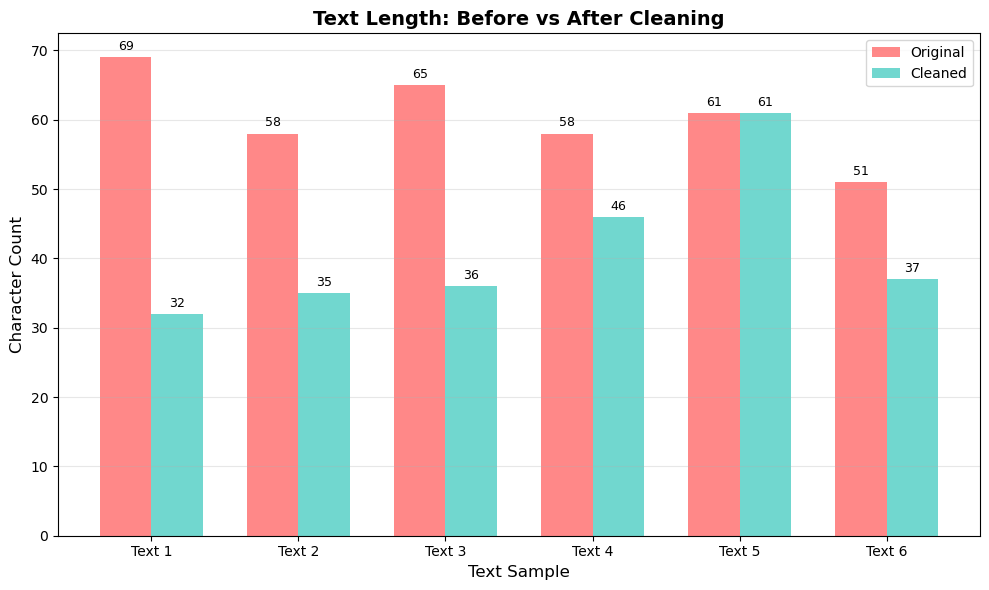

In [18]:
# Visualization 1: Text Length Distribution Before vs After
original_lengths = [len(text) for text in messy_texts]
cleaned_lengths = [len(text) for text in cleaned_texts]

x = np.arange(len(messy_texts))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, original_lengths, width, label='Original', color='#ff6b6b', alpha=0.8)
bars2 = ax.bar(x + width/2, cleaned_lengths, width, label='Cleaned', color='#4ecdc4', alpha=0.8)

ax.set_xlabel('Text Sample', fontsize=12)
ax.set_ylabel('Character Count', fontsize=12)
ax.set_title('Text Length: Before vs After Cleaning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Text {i+1}' for i in range(len(messy_texts))])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


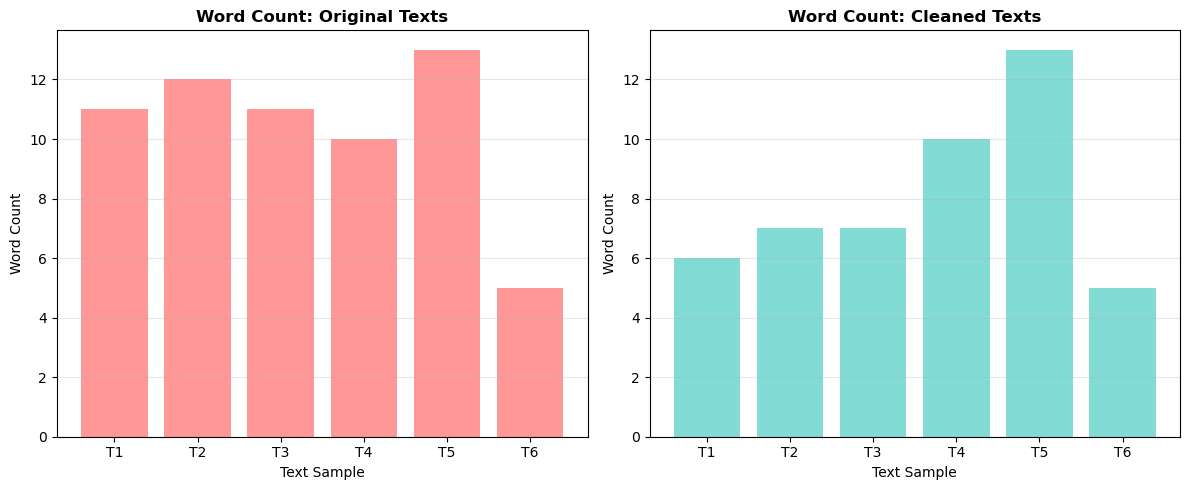


Average word count - Original: 10.3, Cleaned: 8.0


In [19]:
# Visualization 2: Word Count Distribution
def count_words(text):
    return len(re.findall(r'\b\w+\b', text))

original_word_counts = [count_words(text) for text in messy_texts]
cleaned_word_counts = [count_words(text) for text in cleaned_texts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original texts
ax1.bar(range(len(messy_texts)), original_word_counts, color='#ff6b6b', alpha=0.7)
ax1.set_title('Word Count: Original Texts', fontweight='bold')
ax1.set_xlabel('Text Sample')
ax1.set_ylabel('Word Count')
ax1.set_xticks(range(len(messy_texts)))
ax1.set_xticklabels([f'T{i+1}' for i in range(len(messy_texts))])
ax1.grid(axis='y', alpha=0.3)

# Cleaned texts
ax2.bar(range(len(cleaned_texts)), cleaned_word_counts, color='#4ecdc4', alpha=0.7)
ax2.set_title('Word Count: Cleaned Texts', fontweight='bold')
ax2.set_xlabel('Text Sample')
ax2.set_ylabel('Word Count')
ax2.set_xticks(range(len(cleaned_texts)))
ax2.set_xticklabels([f'T{i+1}' for i in range(len(cleaned_texts))])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAverage word count - Original: {np.mean(original_word_counts):.1f}, Cleaned: {np.mean(cleaned_word_counts):.1f}")


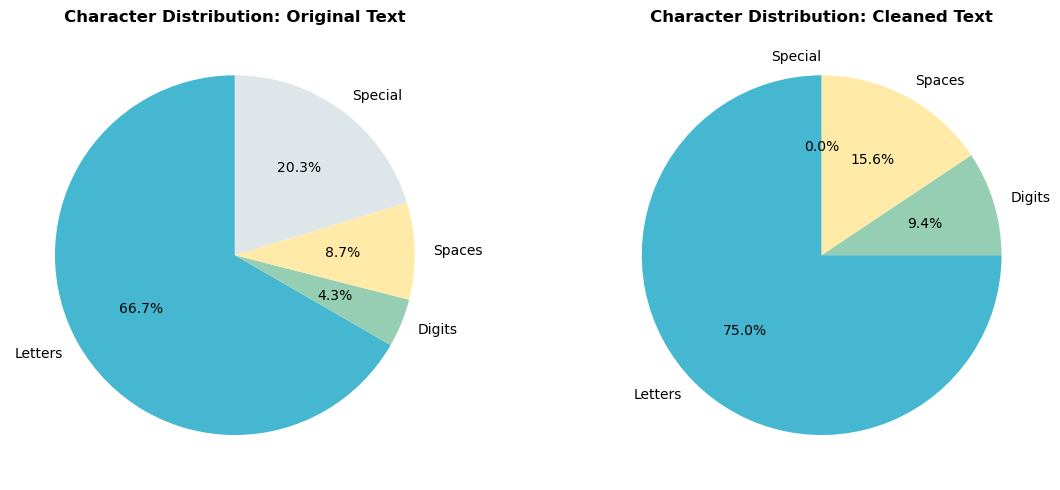

Original: {'Letters': 46, 'Digits': 3, 'Spaces': 6, 'Special': 14}
Cleaned: {'Letters': 24, 'Digits': 3, 'Spaces': 5, 'Special': 0}


In [20]:
# Visualization 3: Character Type Distribution
def analyze_character_types(text):
    """Analyze distribution of character types in text"""
    letters = len(re.findall(r'[a-zA-Z]', text))
    digits = len(re.findall(r'\d', text))
    spaces = len(re.findall(r'\s', text))
    special = len(text) - letters - digits - spaces
    return {'Letters': letters, 'Digits': digits, 'Spaces': spaces, 'Special': special}

# Analyze first text before and after
original_analysis = analyze_character_types(messy_texts[0])
cleaned_analysis = analyze_character_types(cleaned_texts[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#45b7d1', '#96ceb4', '#ffeaa7', '#dfe6e9']

# Original pie chart
ax1.pie(original_analysis.values(), labels=original_analysis.keys(), autopct='%1.1f%%',
        colors=colors, startangle=90)
ax1.set_title('Character Distribution: Original Text', fontweight='bold')

# Cleaned pie chart
ax2.pie(cleaned_analysis.values(), labels=cleaned_analysis.keys(), autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Character Distribution: Cleaned Text', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Original: {original_analysis}")
print(f"Cleaned: {cleaned_analysis}")


<a id='pitfalls'></a>
## ⚠️ Common Pitfalls and Best Practices


### Common Pitfalls

1. **Forgetting to escape special characters**: `.` matches any character, so to match a literal dot use `\.`
2. **Greedy vs Non-greedy confusion**: `.*` matches too much, use `.*?` for minimal matching
3. **Not using raw strings**: Always use `r"pattern"` to avoid Python escape sequence conflicts
4. **Inefficient patterns**: Avoid nested quantifiers like `(a+)+` which can cause catastrophic backtracking
5. **Not validating input**: Regex can fail on edge cases - always test with diverse data


In [26]:
# Demonstrating common pitfalls

# PITFALL 1: Not escaping special characters
text = "Price: $50.00"
wrong_pattern = r"$50"  # $ is anchor, not literal
correct_pattern = r"\$50"
print(f"Wrong (no escape): {re.search(wrong_pattern, text)}")
print(f"Correct (escaped): {re.search(correct_pattern, text).group()}")
print("-" * 50)

# PITFALL 2: Greedy matching issue
html = "<p>First</p><p>Second</p>"
greedy = re.search(r"<p>.*</p>", html)
lazy = re.search(r"<p>.*?</p>", html)
print(f"Greedy (too much): {greedy.group()}")
print(f"Lazy (correct): {lazy.group()}")
print("-" * 50)

# PITFALL 3: Not using raw strings
print(f"Without raw string: {'\n'}")  # Actually creates newline
print(f"With raw string: {r'\n'}")    # Literal backslash-n
print("-" * 50)

# BEST PRACTICE: Compile patterns for reuse
email_pattern = re.compile(r'\S+@\S+\.\S+')
texts = ["Contact a@b.com", "Email c@d.org", "No email here"]
for text in texts:
    match = email_pattern.search(text)
    print(f"Found: {match.group() if match else 'None'}")


Wrong (no escape): None
Correct (escaped): $50
--------------------------------------------------
Greedy (too much): <p>First</p><p>Second</p>
Lazy (correct): <p>First</p>
--------------------------------------------------
Without raw string: 

With raw string: \n
--------------------------------------------------
Found: a@b.com
Found: c@d.org
Found: None


### Best Practices

✅ **Always use raw strings**: `r"pattern"`
✅ **Compile reusable patterns**: `pattern = re.compile(r"...")`
✅ **Use verbose mode for complex patterns**: `re.VERBOSE` allows comments and whitespace
✅ **Test thoroughly**: Use tools like regex101.com or Python's regex debugger
✅ **Document your patterns**: Explain what complex regex does
✅ **Consider readability**: Sometimes multiple simple operations beat one complex regex


In [21]:
# BEST PRACTICE: Using re.VERBOSE for readable complex patterns

phone_pattern = re.compile(r"""
    ^\+?            # Optional + at start
    (\d{1,3})       # Country code (1-3 digits)
    [-\s]?          # Optional separator
    (\d{3})         # Area code (3 digits)
    [-\s]?          # Optional separator  
    (\d{3})         # Prefix (3 digits)
    [-\s]?          # Optional separator
    (\d{4})$        # Line number (4 digits)
""", re.VERBOSE)

test_numbers = [
    "+1-800-555-1234",
    "8005551234",
    "800-555-1234",
    "+44 207 123 4567"
]

for number in test_numbers:
    match = phone_pattern.match(number)
    if match:
        print(f"✓ Valid: {number} → Groups: {match.groups()}")
    else:
        print(f"✗ Invalid: {number}")


✓ Valid: +1-800-555-1234 → Groups: ('1', '800', '555', '1234')
✗ Invalid: 8005551234
✗ Invalid: 800-555-1234
✓ Valid: +44 207 123 4567 → Groups: ('44', '207', '123', '4567')


---

<a id='exercises'></a>
## 🛠️ Hands-On Exercises

Complete these exercises to reinforce your regex skills. Each exercise builds on the previous ones.

### Exercise 1: Basic Pattern Matching
Write a regex pattern to match words that start with 'p' and end with 'n'.


In [22]:
# Exercise 1: Your code here
test_string = "python pattern person passion pollution pythonic"



### Exercise 2: Extract Email Domains
Extract just the domain part (after @) from email addresses.


In [23]:
# Exercise 2: Your code here
emails = ["user@gmail.com", "admin@company.org", "test@sub.domain.co.uk"]



### Exercise 3: Validate Phone Numbers
Create a pattern to validate US phone numbers in format: (XXX) XXX-XXXX


In [24]:
# Exercise 3: Your code here
phone_numbers = ["(555) 123-4567", "(123)456-7890", "555-123-4567", "(555) 123-456"]



### Exercise 4: Extract Hashtags
Extract all hashtags from a tweet, including the # symbol.


In [25]:
# Exercise 4: Your code here
tweet = "Loving #Python and #Regex! #Coding #AI #100DaysOfCode"



### Exercise 5: Remove All Digits
Remove all digits from a string, but keep the rest of the text intact.


In [27]:
# Exercise 5: Your code here
text_with_numbers = "Order #12345 placed on 2024-03-15 for $99.99"



### Exercise 6: Find Repeated Words
Find all instances where a word is immediately repeated (e.g., "the the").


In [28]:
# Exercise 6: Your code here
text = "This is is a test test to find repeated repeated words in in this text."



### Exercise 7: Extract Dates in MM/DD/YYYY Format
Extract dates in MM/DD/YYYY format and convert them to YYYY-MM-DD format.


In [29]:
# Exercise 7: Your code here
text = "Meeting on 03/15/2024 and follow-up on 04/01/2024"



### Exercise 8: Validate Password Strength
Create a regex to validate passwords that must:
- Be at least 8 characters
- Contain at least one uppercase letter
- Contain at least one lowercase letter
- Contain at least one digit
- Contain at least one special character (!@#$%^&*)


In [30]:
# Exercise 8: Your code here
passwords = ["Weak1", "Strong1!", "strong1!", "STRONG1!", "StrongPass!"]



### Exercise 9: Parse Log Entries
Parse Apache log entries to extract IP address, timestamp, and HTTP status code.


In [31]:
# Exercise 9: Your code here
log_entry = '192.168.1.1 - - [15/Mar/2024:14:30:15 +0000] "GET /index.html HTTP/1.1" 200 1234'



### Exercise 10: Build a Reusable TextPreprocessor Class
Create a class that encapsulates all the cleaning functions we built, with configurable options.


In [32]:
# Exercise 10: Your code here
class TextPreprocessor:
    def __init__(self):
        pass
    
    def clean(self, text):
        pass

# Test your class
preprocessor = TextPreprocessor()
test_text = "Check https://example.com!!! Contact john@email.com #AI @user"
# result = preprocessor.clean(test_text)
# print(result)


---

<a id='solutions'></a>
## ✅ Solutions (Try First Before Checking!)


In [ ]:
test_string = "python pattern person passion pollution pythonic"
pattern = r"\bp\w+n\b"
result = re.findall(pattern, test_string)
print(f"Exercise 1 - Words starting with 'p' and ending with 'n': {result}")
print(r"Explanation: \b ensures word boundaries, p\w+n matches p, word chars, n")

Exercise 1 - Words starting with 'p' and ending with 'n': ['python', 'pattern', 'person', 'passion', 'pollution']
Explanation: ensures word boundaries, p\w+n matches p, word chars, n


<>:6: SyntaxWarning: invalid escape sequence '\w'
<>:6: SyntaxWarning: invalid escape sequence '\w'
C:\Users\786\AppData\Local\Temp\ipykernel_15660\1579110568.py:6: SyntaxWarning: invalid escape sequence '\w'
  print("Explanation: \b ensures word boundaries, p\w+n matches p, word chars, n")


In [34]:
# Solution 2: Extract Email Domains
emails = ["user@gmail.com", "admin@company.org", "test@sub.domain.co.uk"]
pattern = r"@([\w.]+)"
for email in emails:
    match = re.search(pattern, email)
    if match:
        print(f"Email: {email} → Domain: {match.group(1)}")


Email: user@gmail.com → Domain: gmail.com
Email: admin@company.org → Domain: company.org
Email: test@sub.domain.co.uk → Domain: sub.domain.co.uk


In [35]:
# Solution 3: Validate Phone Numbers
phone_numbers = ["(555) 123-4567", "(123)456-7890", "555-123-4567", "(555) 123-456"]
pattern = r"^\(\d{3}\)\s?\d{3}-\d{4}$"
for phone in phone_numbers:
    if re.match(pattern, phone):
        print(f"✓ Valid: {phone}")
    else:
        print(f"✗ Invalid: {phone}")


✓ Valid: (555) 123-4567
✓ Valid: (123)456-7890
✗ Invalid: 555-123-4567
✗ Invalid: (555) 123-456


In [36]:
# Solution 4: Extract Hashtags
tweet = "Loving #Python and #Regex! #Coding #AI #100DaysOfCode"
pattern = r"#\w+"
hashtags = re.findall(pattern, tweet)
print(f"Exercise 4 - Hashtags found: {hashtags}")


Exercise 4 - Hashtags found: ['#Python', '#Regex', '#Coding', '#AI', '#100DaysOfCode']


In [37]:
# Solution 5: Remove All Digits
text_with_numbers = "Order #12345 placed on 2024-03-15 for $99.99"
pattern = r"\d"
result = re.sub(pattern, "", text_with_numbers)
print(f"Exercise 5 - Without digits: {result}")


Exercise 5 - Without digits: Order # placed on -- for $.


In [39]:
text = "This is is a test test to find repeated repeated words in in this text."
pattern = r"\b(\w+)\s+\1\b"
matches = re.findall(pattern, text)
print(f"Exercise 6 - Repeated words: {matches}")
print(r"Explanation: (\w+) captures word, \s+ matches space, \1 references captured group")

Exercise 6 - Repeated words: ['is', 'test', 'repeated', 'in']
Explanation: (\w+) captures word, \s+ matches space, \1 references captured group


In [40]:
# Solution 7: Extract and Convert Dates
text = "Meeting on 03/15/2024 and follow-up on 04/01/2024"
pattern = r"(\d{2})/(\d{2})/(\d{4})"
def convert_date(match):
    return f"{match.group(3)}-{match.group(1)}-{match.group(2)}"
result = re.sub(pattern, convert_date, text)
print(f"Exercise 7 - Converted dates: {result}")


Exercise 7 - Converted dates: Meeting on 2024-03-15 and follow-up on 2024-04-01


In [41]:
# Solution 8: Validate Password Strength
passwords = ["Weak1", "Strong1!", "strong1!", "STRONG1!", "StrongPass!"]
# Using lookahead assertions
pattern = r"^(?=.*[A-Z])(?=.*[a-z])(?=.*\d)(?=.*[!@#$%^&*]).{8,}$"
for pwd in passwords:
    if re.match(pattern, pwd):
        print(f"✓ '{pwd}' is strong")
    else:
        print(f"✗ '{pwd}' is weak")


✗ 'Weak1' is weak
✓ 'Strong1!' is strong
✗ 'strong1!' is weak
✗ 'STRONG1!' is weak
✗ 'StrongPass!' is weak


In [42]:
# Solution 9: Parse Log Entries
log_entry = '192.168.1.1 - - [15/Mar/2024:14:30:15 +0000] "GET /index.html HTTP/1.1" 200 1234'
pattern = r'^(\S+)\s+\S+\s+\S+\s+\[([^\]]+)\]\s+"[^"]+"\s+(\d+)'
match = re.search(pattern, log_entry)
if match:
    print(f"Exercise 9 - Parsed log entry:")
    print(f"  IP: {match.group(1)}")
    print(f"  Timestamp: {match.group(2)}")
    print(f"  Status: {match.group(3)}")


Exercise 9 - Parsed log entry:
  IP: 192.168.1.1
  Timestamp: 15/Mar/2024:14:30:15 +0000
  Status: 200


In [43]:
# Solution 10: Reusable TextPreprocessor Class
import re

class TextPreprocessor:
    def __init__(self, lowercase=True, remove_urls=True, remove_emails=True,
                 remove_numbers=False, remove_punctuation=False):
        self.lowercase = lowercase
        self.remove_urls = remove_urls
        self.remove_emails = remove_emails
        self.remove_numbers = remove_numbers
        self.remove_punctuation = remove_punctuation
        
        # Compile reusable patterns
        self.url_pattern = re.compile(r'https?://\S+|www\.\S+')
        self.email_pattern = re.compile(r'\S+@\S+\.\S+')
        self.number_pattern = re.compile(r'\d+')
        self.punct_pattern = re.compile(r'[^\w\s]')
        self.whitespace_pattern = re.compile(r'\s+')
    
    def clean(self, text):
        """Apply all cleaning steps based on configuration"""
        if self.remove_urls:
            text = self.url_pattern.sub('[URL]', text)
        
        if self.remove_emails:
            text = self.email_pattern.sub('[EMAIL]', text)
        
        if self.remove_numbers:
            text = self.number_pattern.sub('', text)
        
        if self.remove_punctuation:
            text = self.punct_pattern.sub('', text)
        
        # Normalize whitespace
        text = self.whitespace_pattern.sub(' ', text).strip()
        
        if self.lowercase:
            text = text.lower()
        
        return text

# Test the class
preprocessor = TextPreprocessor()
test_text = "Check https://example.com!!! Contact john@email.com #AI @user"
result = preprocessor.clean(test_text)
print(f"Exercise 10 - Preprocessor result: {result}")

# Test with different configuration
preprocessor2 = TextPreprocessor(remove_punctuation=True, remove_numbers=True)
result2 = preprocessor2.clean("Price: $50, Count: 100 items!!!")
print(f"With punctuation removal: {result2}")


Exercise 10 - Preprocessor result: check [url] contact [email] #ai @user
With punctuation removal: price count items
